# **1. Lectura de paquetes y data**


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.api import ExponentialSmoothing, ARIMA
from itertools import product
import matplotlib.pyplot as plt
import warnings
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch
from scipy.stats import shapiro, jarque_bera
import seaborn as sns
import statsmodels.api as sm
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore")

Utilizamos paths relativos para la lectura de la data

In [2]:
filename = "Evaluacion_modelos_st.ipynb"  # nombre del archivo actual
print(f"Current absolute path: {os.getcwd()}\n")

# Especificamos la ruta del directorio actual y los directorios de datos y salida
ACTUAL_DIR = os.path.dirname(os.path.abspath(filename))
BASE_DIR = os.path.dirname(ACTUAL_DIR)
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(DATA_DIR, "output")

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

Current absolute path: C:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Proyecto de Innovacion Tecnologica\Taller Final\innv_tec_1_icesi\notebooks

BASE_DIR: C:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Proyecto de Innovacion Tecnologica\Taller Final\innv_tec_1_icesi
DATA_DIR: C:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Proyecto de Innovacion Tecnologica\Taller Final\innv_tec_1_icesi\data
OUTPUT_DIR: C:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Proyecto de Innovacion Tecnologica\Taller Final\innv_tec_1_icesi\data\output


In [3]:
# Cargar el archivo de Excel
file_path = os.path.join(DATA_DIR, "data_demanda.xlsx")
df_base = pd.read_excel(file_path, sheet_name="data")
df_base = df_base.drop("Cliente", axis=1)

In [4]:
df_base

,Fe.prefer.entrega,Day_of_the_Week,Pedidos,Sell_In,Sell_in_on_time,CEDIS,SKU,Mes_Año,Sell_in_rezago,porcentaje_on_time,Subcategoria
0,2024-07-05,Friday,16200,16200,16200,7,SKU7,72024,0,1.000000,BEBIDAS DE YOGUR
1,2024-07-05,Friday,19800,19800,19800,6,SKU5,72024,0,1.000000,BEBIDAS DE YOGUR
2,2024-07-05,Friday,4950,4950,4950,4,SKU6,72024,0,1.000000,BEBIDAS DE YOGUR
3,2024-07-05,Friday,8100,8100,8100,6,SKU4,72024,0,1.000000,BEBIDAS DE YOGUR
4,2024-07-05,Friday,18600,18600,18600,7,SKU3,72024,0,1.000000,BEBIDAS DE YOGUR
...,...,...,...,...,...,...,...,...,...,...,...
6829,2025-04-10,Thursday,1560,1560,1560,2,SKU14,42025,0,1.000000,FIOCOSSOS
6830,2025-04-10,Thursday,3900,3900,3900,2,SKU16,42025,0,1.000000,LECHE PASTEURIZADA
6831,2025-04-10,Thursday,4200,0,0,3,SKU8,42025,0,0.000000,YOGUR BOTELLA
6832,2025-04-10,Thursday,2160,1764,1764,3,SKU22,42025,0,0.816667,YOGUR VASOS


In [5]:
# Filtrar los datos relevantes para este analisis

df = (
    df_base[["Fe.prefer.entrega", "SKU", "Pedidos"]]
    .copy()
    .rename(
        columns={
            "Fe.prefer.entrega": "Fecha",
        }
    )
)
df["Pedidos"] = pd.to_numeric(df["Pedidos"], errors="coerce")

In [6]:
df=df[df["SKU"]=="SKU8"]

In [7]:
### Primero, nos aseguramos de que se cuente un dato por SKU por dia
# -------

# rango completo de fechas desde la más antigua hasta la más reciente
fecha_min = df["Fecha"].min()
fecha_max = df["Fecha"].max()
rango_fechas = pd.date_range(start=fecha_min, end=fecha_max, freq="D")

# Obtenemos todos los SKUs únicos
skus = df["SKU"].unique()

# DataFrame con todas las combinaciones de SKU y fecha
combinaciones_completas = pd.MultiIndex.from_product(
    [rango_fechas, skus], names=["Fecha", "SKU"]
).to_frame(index=False)

# Unir con el dataframe original para rellenar con ceros donde falten datos
df_completo = combinaciones_completas.merge(df, on=["Fecha", "SKU"], how="left")

# Rellenar valores faltantes de pedidos con 0
df_completo["Pedidos"] = df_completo["Pedidos"].fillna(0).astype(int)

# Ordenar por SKU y Fecha (opcional)
df_completo = df_completo.sort_values(["SKU", "Fecha"]).reset_index(drop=True)

df = df_completo.copy()

In [8]:
df

,Fecha,SKU,Pedidos
0,2024-07-05,SKU8,1332
1,2024-07-06,SKU8,120
2,2024-07-07,SKU8,120
3,2024-07-08,SKU8,300
4,2024-07-09,SKU8,960
...,...,...,...
275,2025-04-06,SKU8,0
276,2025-04-07,SKU8,0
277,2025-04-08,SKU8,4500
278,2025-04-09,SKU8,5160


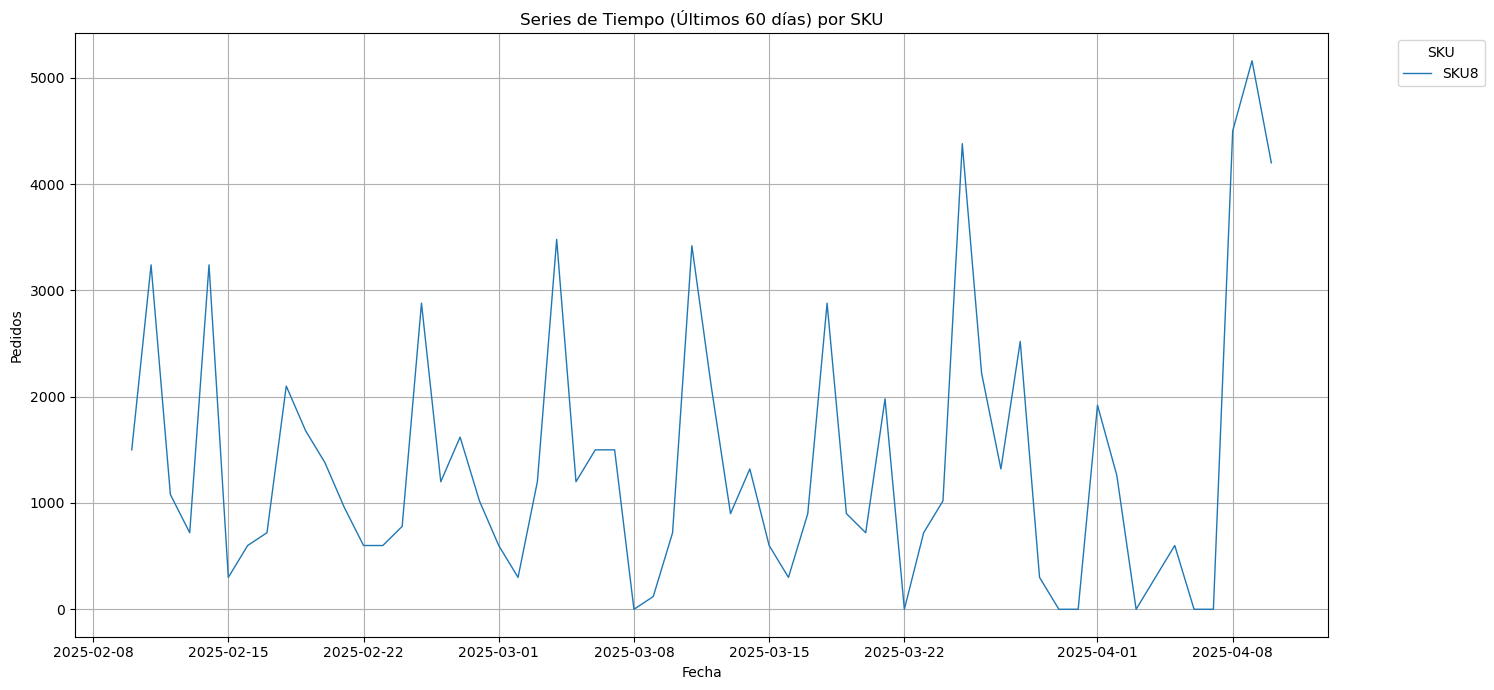

In [9]:
### Grafico de series de tiempo para todos los SKU (ultimos 60 dias)
# ----

# Calcular la fecha límite: últimos 60 días desde la fecha máxima
fecha_max = df["Fecha"].max()
fecha_min = fecha_max - pd.Timedelta(days=59)

# Filtrar el DataFrame a los últimos 60 días
df_ultimos_60 = df[df["Fecha"].between(fecha_min, fecha_max)]

plt.figure(figsize=(15, 7))

# Graficar cada serie de tiempo por SKU
for sku in df_ultimos_60["SKU"].unique():
    datos_sku = df_ultimos_60[df_ultimos_60["SKU"] == sku]
    plt.plot(datos_sku["Fecha"], datos_sku["Pedidos"], label=sku, linewidth=1)

# Títulos y etiquetas
plt.title("Series de Tiempo (Últimos 60 días) por SKU")
plt.xlabel("Fecha")
plt.ylabel("Pedidos")
plt.legend(
    title="SKU", bbox_to_anchor=(1.05, 1), loc="upper left"
)  # Mueve la leyenda fuera del gráfico
plt.tight_layout()
plt.grid(True)

# Mostrar la gráfica
plt.show()

# **3. Corrección de Outliers**

Con el objetivo de evitar valores puntuales considerados como outliers con potencial de afectar el entrenamiento o proyección, se realiza una corrección **POR SKU**

In [10]:
# Corregir outliers por SKU
def correct_outliers(group):
    series = group["Pedidos"].copy()
    mean = series.mean()
    std = series.std()
    lower = mean - 2 * std
    upper = mean + 2 * std
    series = series.apply(lambda x: lower if x < lower else upper if x > upper else x)
    group["Pedidos_Clean"] = series
    return group


df_cleaned = df.groupby("SKU").apply(correct_outliers).reset_index(drop=True)

In [11]:
df_cleaned[["Pedidos", "Pedidos_Clean"]].describe()

,Pedidos,Pedidos_Clean
count,280.000000,280.000000
mean,941.507143,898.186128
std,907.062548,776.831490
min,0.000000,0.000000
25%,300.000000,300.000000
50%,720.000000,720.000000
75%,1320.000000,1320.000000
max,5160.000000,2755.632239


# **4. Funciones de evaluación y modelos**

Procedemos a definir funciones para evaluar modelos de series de tiempo, específicamente los modelos Holt-Winters (suavizamiento exponencial) y ARIMA, aplicando una búsqueda en rejilla (grid search) sobre distintos parámetros. 

El objetivo es encontrar la configuración con mejor desempeño, evaluada mediante métricas como MAE, RMSE y MAPE.

In [12]:
# Divide una serie en entrenamiento y prueba
def split_series(series, test_size=7):
    return series[:-test_size], series[-test_size:]

def diagnostico_arima(modelo):
    resid = modelo.resid

    print("=== Diagnóstico de Supuestos ARIMA ===\n")

    # 1. Autocorrelación de residuos (Ljung-Box)
    print(">> Prueba de autocorrelación (Ljung-Box)")
    ljung = acorr_ljungbox(resid, lags=[10], return_df=True)
    print(ljung, "\n")

    # 2. Homoscedasticidad (ARCH Test)
    print(">> Prueba de homoscedasticidad (ARCH)")
    arch_test = het_arch(resid)
    print(f"ARCH LM stat: {arch_test[0]:.4f}, p-value: {arch_test[1]:.4f}\n")

    # 3. Normalidad de los residuos
    print(">> Pruebas de normalidad")
    shapiro_stat, shapiro_p = shapiro(resid)
    jb_stat, jb_p = jarque_bera(resid)
    print(f"Shapiro-Wilk: stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
    print(f"Jarque-Bera: stat={jb_stat:.4f}, p-value={jb_p:.4f}\n")

    # Gráficos
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Residuos vs tiempo
    axes[0, 0].plot(resid)
    axes[0, 0].set_title("Residuos vs Tiempo")

    # ACF
    plot_acf(resid, lags=30, ax=axes[0, 1])
    axes[0, 1].set_title("ACF de los residuos")

    # Histograma
    sns.histplot(resid, bins=20, kde=True, ax=axes[1, 0])
    axes[1, 0].set_title("Histograma de residuos")

    # QQ Plot
    sm.qqplot(resid, line='s', ax=axes[1, 1])
    axes[1, 1].set_title("QQ-Plot")

    plt.tight_layout()
    plt.show()

    return {
        "ljung_box_pvalue": ljung["lb_pvalue"].iloc[0],
        "arch_pvalue": arch_test[1],
        "shapiro_pvalue": shapiro_p,
        "jarque_bera_pvalue": jb_p
    }
# Evalúa múltiples configuraciones del modelo ARIMA y devuelve la mejor
def evaluate_arima(train, test):
    best_result = None  # Para almacenar el mejor resultado

    # Prueba combinaciones de parámetros (p, d, q) desde 0 hasta 2
    #for p, d, q in product(range(3), repeat=3):
    #    try:
            # Ajusta el modelo ARIMA con la configuración actual
    model = ARIMA(train, order=(0, 0, 1)).fit()

            # Pronostica para el conjunto de prueba
    forecast = model.forecast(steps=len(test))
        
            # Evaluacion de Supuestos
    print(diagnostico_arima(model))


    return None

# **5. Evaluación de Modelos**

A continuación, implementamos un pipeline automatizado para:
- Evaluar modelos de series de tiempo (ARIMA y Holt-Winters) para cada SKU.
- Seleccionar el mejor modelo por SKU en función del RMSE.
- Guardar un resumen de las métricas de desempeño y el pronóstico generado.

También utilizamos el paquete tqdm para mostrar una barra de progreso durante la ejecución.

Evaluando SKUs:   0%|          | 0/1 [00:00<?, ?it/s]

=== Diagnóstico de Supuestos ARIMA ===

>> Prueba de autocorrelación (Ljung-Box)
       lb_stat     lb_pvalue
10  108.995051  8.506962e-19 

>> Prueba de homoscedasticidad (ARCH)
ARCH LM stat: 55.0945, p-value: 0.0000

>> Pruebas de normalidad
Shapiro-Wilk: stat=0.9191, p-value=0.0000
Jarque-Bera: stat=42.3578, p-value=0.0000



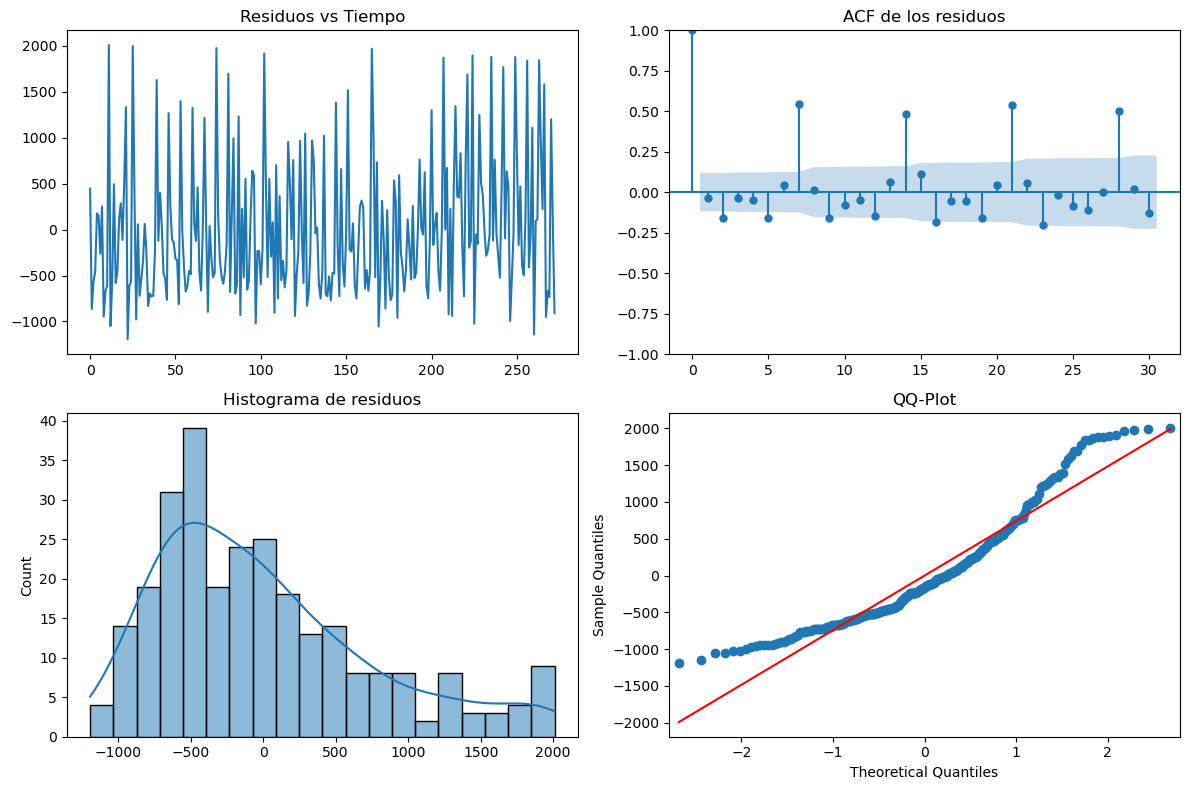

Evaluando SKUs: 100%|██████████| 1/1 [00:00<00:00,  1.91it/s]

{'ljung_box_pvalue': 8.506962121726013e-19, 'arch_pvalue': 3.032223570166991e-08, 'shapiro_pvalue': 5.374003086627153e-11, 'jarque_bera_pvalue': 6.340362837250331e-10}


""


In [13]:
# Automatizar evaluación y forecasting para todos los SKUs
from tqdm import tqdm  # para barra de progreso (opcional en Colab)


# Función principal que automatiza el proceso de modelado por SKU
def run_full_forecast_pipeline(df, seasonal_periods=7):
    skus = df["SKU"].unique()
    forecast_results = []

    # Itera sobre cada SKU con barra de progreso
    for sku in tqdm(skus, desc="Evaluando SKUs"):

        # Extrae la serie temporal del SKU actual (ya corregida de outliers)
        series = df[df["SKU"] == sku]["Pedidos_Clean"].reset_index(drop=True)

        # Divide la serie en entrenamiento y prueba
        train, test = split_series(series)

        results = []  # Lista para guardar los resultados de los modelos evaluados

        # --- Modelo ARIMA ---
        arima_result = evaluate_arima(train, test)
        if arima_result:
            results.append(arima_result)  # Guarda resultado si fue exitoso

        # Ordena los resultados por RMSE (menor es mejor)
        results_sorted = sorted(results, key=lambda x: x["rmse"])
        best_result = (
            results_sorted[0] if results_sorted else None
        )  # Toma el mejor modelo

        # Si hay al menos un resultado válido, guarda el resumen
        if best_result:
            forecast_results.append(
                {
                    "SKU": sku,
                    "Best_Model": best_result[
                        "model"
                    ],  # Nombre/configuración del mejor modelo
                    "MAE": best_result["mae"],
                    "RMSE": best_result["rmse"],
                    "MAPE": best_result["mape"],
                    "Forecast": best_result[
                        "forecast"
                    ],  # Lista de valores pronosticados
                }
            )

    # Devuelve un DataFrame con los resultados para todos los SKUs
    return pd.DataFrame(forecast_results)


# Ejecutar el pipeline completo
df_forecast_summary = run_full_forecast_pipeline(df_cleaned)

# Mostrar resultados
df_forecast_summary.head(100)

**No cumple los supuestos de autocorrelacion de los residuos, homoscedasticidad y normalidad**